This code analyses the data to ensure that they are balanced and usable to train the model and plot some histograms for the report. 

In [76]:
import pandas as pd

data = pd.read_parquet('congress_tweets_dataset_cleaned.parquet')

ArrowMemoryError: malloc of size 886341952 failed

In [ ]:
print("number of tweets per party :")
print(data["label"].value_counts())
print("\n")

#number of unique users per party
user_counts = data.groupby('label')['user_id'].nunique()
print("number of unique users per party : ")
print(user_counts)
print("\n")

number of tweets per party :
label
D    2567079
R    1785196
Name: count, dtype: int64


number of unique users per party : 
label
D    683
R    772
Name: user_id, dtype: int64




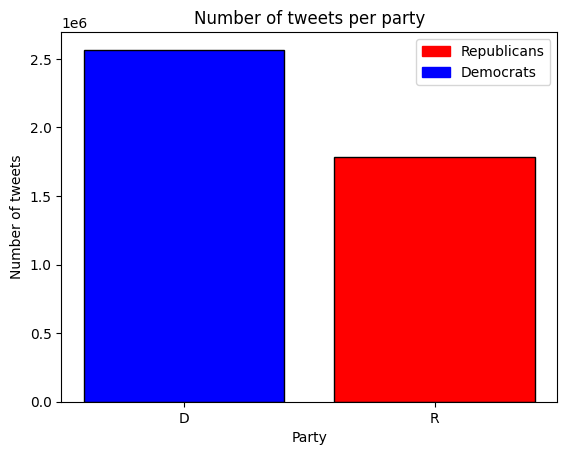

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

tweet_counts = data["label"].value_counts()

plt.bar(tweet_counts.index, tweet_counts.values, color=['blue', 'red'], edgecolor='black')
plt.xlabel('Party')
plt.ylabel('Number of tweets')
plt.title('Number of tweets per party')

red_patch = mpatches.Patch(color='red', label='Republicans')
blue_patch = mpatches.Patch(color='blue', label='Democrats')
plt.legend(handles=[red_patch, blue_patch])

plt.savefig('distribution_tweets.pdf', bbox_inches='tight')
plt.show()

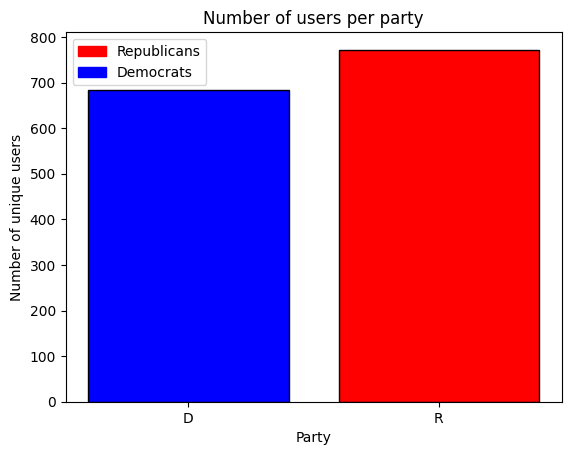

In [ ]:
user_counts = data.groupby("label")["user_id"].nunique()

plt.bar(user_counts.index, user_counts.values, color=['blue', 'red'], edgecolor='black')

plt.xlabel('Party')
plt.ylabel('Number of unique users')
plt.title('Number of users per party')

# Ajuster les ticks pour que 0 et 1 soient bien centrés

red_patch = mpatches.Patch(color='red', label='Republicans')
blue_patch = mpatches.Patch(color='blue', label='Democrats')
plt.legend(handles=[red_patch, blue_patch])
plt.savefig('distribution_users.pdf', bbox_inches='tight')

plt.show()

In [77]:
user_stats = data.groupby(['user_id', 'label']).size().reset_index(name='tweet_count')

user_stats = user_stats.sort_values(['label', 'tweet_count'], ascending=[True, False])


#we replace the user_id with the name of the acounts 

users_data = pd.read_json('historical-users-filtered.json')

users_expanded = users_data.explode('accounts')

def extract_info(acc):
    if isinstance(acc, dict):
        return pd.Series([str(acc.get('id')), acc.get('screen_name')])
    return pd.Series([None, None])

mapping_screen_name = users_expanded['accounts'].apply(extract_info)
mapping_screen_name.columns = ['user_id', 'screen_name']

user_stats['user_id'] = user_stats['user_id'].astype(str)

users_stat_screen_names = pd.merge(user_stats, mapping_screen_name, on='user_id', how='left')

top_5_rep = users_stat_screen_names[users_stat_screen_names['label'] == "D"].nlargest(5, 'tweet_count')
top_5_dem = users_stat_screen_names[users_stat_screen_names['label'] == "R"].nlargest(5, 'tweet_count')

most_active_users = pd.concat([top_5_rep, top_5_dem])


tweet_counts = data["label"].value_counts()
democrat_tweet_count = tweet_counts.get("D", 0)
republican_tweet_count = tweet_counts.get("R", 0)

most_active_users["% of tweets relatively to the party"] = most_active_users.apply(lambda row: round(100*row["tweet_count"] / democrat_tweet_count, 2) if row["label"] == "D" else round(100*row["tweet_count"] / republican_tweet_count, 2), axis=1)

display(most_active_users[["screen_name","label","tweet_count","% of tweets relatively to the party"]])



,screen_name,label,tweet_count,% of tweets relatively to the party
0,RepDonBeyer,D,30809,1.20
1,HispanicCaucus,D,30321,1.18
2,RepJayapal,D,25785,1.00
3,RepDwightEvans,D,23438,0.91
4,SenateDems,D,21079,0.82
683,auctnr1,R,69309,3.88
684,chiproytx,R,38337,2.15
685,JohnCornyn,R,30371,1.70
686,HouseGOP,R,28183,1.58
687,tedcruz,R,22659,1.27
